# Twitter Sentiment Analysis

Build a small NLP model that labels a short post as **positive** or **negative**. We will clean the text, turn words into TF-IDF features, train logistic regression, evaluate it, and try our own messages.

**Dataset:** local labeled social-post examples included in `data/twitter_sentiment.csv`.

All code, explanations, and data used by this project are included in this repository.

## 1. Set up the experiment

Install `numpy`, `pandas`, `matplotlib`, `seaborn`, and `scikit-learn`. The fixed seed makes the split and model repeatable.

In [1]:
from pathlib import Path
import html
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

## 2. Load labeled posts

The local CSV supplies balanced positive and negative examples, so no social-media API, credentials, or runtime download is needed.

In [2]:
DATA_PATH = Path("data/twitter_sentiment.csv") if Path("data/twitter_sentiment.csv").exists() else Path("../data/twitter_sentiment.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Run this notebook from the repository root so data/ is available.")

data = pd.read_csv(DATA_PATH).dropna(subset=["text", "label"])
data["label"] = data["label"].astype("int32")
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Local dataset rows: {len(data):,}")
display(data.sample(min(5, len(data)), random_state=SEED))
display(data["label"].map({0: "negative", 1: "positive"}).value_counts())

Local dataset rows: 2,400


,text,label
2037,"In my view, I criticise the new feature becaus...",0
1978,"After trying it, I regret today's session beca...",0
855,"Today, I celebrate this update because it work...",1
1719,"Honestly, I criticise the delivery because the...",0
2019,"In my view, I love the workshop because the id...",1


label
negative    1200
positive    1200
Name: count, dtype: int64

## 3. Clean the text

URLs, usernames, and retweet markers usually identify *where* a post came from, not its opinion. We remove those signals, keep hashtag words, normalize punctuation, and lowercase the result.

In [3]:
def clean_post(text):
    text = html.unescape(str(text))
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\bRT\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"[^a-zA-Z']+", " ", text)
    return re.sub(r"\s+", " ", text).strip().lower()

data["clean_text"] = data["text"].map(clean_post)
display(data[["text", "clean_text"]].head(6))

,text,clean_text
0,"After trying it, I doubt this update because i...",after trying it i doubt this update because it...
1,"Today, I enjoy today's session because it work...",today i enjoy today's session because it works...
2,"Right now, I criticise the new feature because...",right now i criticise the new feature because ...
3,"Honestly, I appreciate the service because the...",honestly i appreciate the service because the ...
4,"After trying it, I criticise the service becau...",after trying it i criticise the service becaus...
5,"For me, I avoid the service because the qualit...",for me i avoid the service because the quality...


## 4. Make a fair train/test split

The model learns from 80% of the posts and is tested on the untouched 20%. `stratify` keeps the positive/negative balance the same in both groups.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    data["clean_text"],
    data["label"],
    test_size=0.20,
    random_state=SEED,
    stratify=data["label"],
)
print(f"Training posts: {len(X_train):,} | Test posts: {len(X_test):,}")

Training posts: 1,920 | Test posts: 480


## 5. Turn words into features and train

TF-IDF gives more weight to useful words and short phrases. Logistic regression then learns which features push a prediction toward positive or negative. Keeping both steps in one pipeline prevents train/test leakage.

In [5]:
sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=8_000,
        sublinear_tf=True,
    )),
    ("classifier", LogisticRegression(max_iter=1_000, random_state=SEED)),
])
sentiment_model.fit(X_train, y_train)
feature_count = len(sentiment_model.named_steps["tfidf"].get_feature_names_out())
print(f"Model trained with {feature_count:,} TF-IDF features.")

Model trained with 275 TF-IDF features.


## 6. Evaluate on unseen posts

Accuracy gives one headline number. The classification report separates performance by class, while the confusion matrix shows exactly which labels were mixed up.

Accuracy: 1.000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       240
    positive       1.00      1.00      1.00       240

    accuracy                           1.00       480
   macro avg       1.00      1.00      1.00       480
weighted avg       1.00      1.00      1.00       480



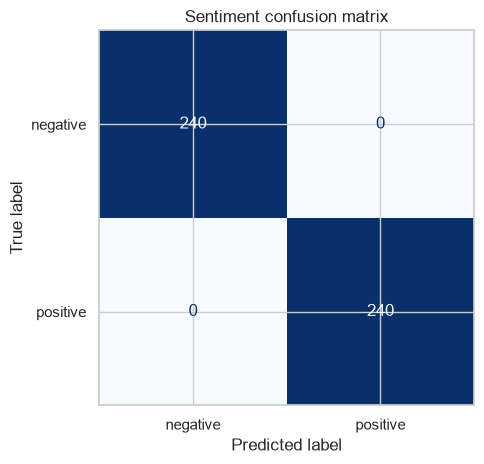

In [6]:
test_predictions = sentiment_model.predict(X_test)
accuracy = accuracy_score(y_test, test_predictions)
print(f"Accuracy: {accuracy:.3f}")
print()
print(classification_report(
    y_test, test_predictions, target_names=["negative", "positive"]
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Sentiment confusion matrix")
plt.tight_layout()
plt.show()

## 7. Inspect what the model learned

A positive coefficient raises the positive score; a negative coefficient lowers it. These influential features are clues—not proof that the model understands language.

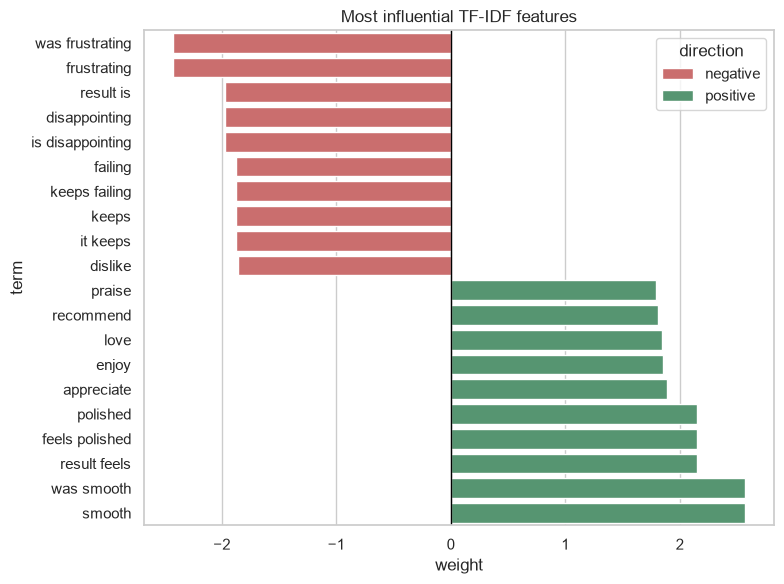

In [7]:
terms = sentiment_model.named_steps["tfidf"].get_feature_names_out()
weights = sentiment_model.named_steps["classifier"].coef_[0]
top_n = min(10, len(terms) // 2)
negative_ids = np.argsort(weights)[:top_n]
positive_ids = np.argsort(weights)[-top_n:]
chosen_ids = np.concatenate([negative_ids, positive_ids])

important = pd.DataFrame({
    "term": terms[chosen_ids],
    "weight": weights[chosen_ids],
    "direction": ["negative"] * top_n + ["positive"] * top_n,
}).sort_values("weight")

plt.figure(figsize=(8, 6))
sns.barplot(
    data=important, x="weight", y="term", hue="direction",
    dodge=False, palette={"negative": "#d95f5f", "positive": "#4c9f70"}
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Most influential TF-IDF features")
plt.tight_layout()
plt.show()

## 8. Try new posts

The probability is a confidence-like model score, not a guarantee. Because this model is binary, even a neutral or mixed sentence must be assigned one of the two labels.

In [8]:
def predict_sentiment(posts):
    cleaned = [clean_post(post) for post in posts]
    positive_probability = sentiment_model.predict_proba(cleaned)[:, 1]
    return pd.DataFrame({
        "post": posts,
        "prediction": np.where(positive_probability >= 0.5, "positive", "negative"),
        "positive_probability": positive_probability.round(3),
    })

demo_posts = [
    "Coffee with CodeCell was inspiring and fun!",
    "The app crashed again and I lost my work.",
    "The update is okay, but the setup took too long.",
]
display(predict_sentiment(demo_posts))

,post,prediction,positive_probability
0,Coffee with CodeCell was inspiring and fun!,negative,0.420
1,The app crashed again and I lost my work.,positive,0.544
2,"The update is okay, but the setup took too long.",negative,0.193


## Where to go next

Try character n-grams for misspellings, add a neutral class, inspect incorrect predictions, or swap in the larger Sentiment140 CSV used by many tutorials. Real posts can contain sarcasm, dialect, code-switching, and shifting slang, so check performance across groups and time before any real use.